In [1]:
import json
import os
import matplotlib.pyplot as plt

Plot saved to figs/step1_training_stats.png


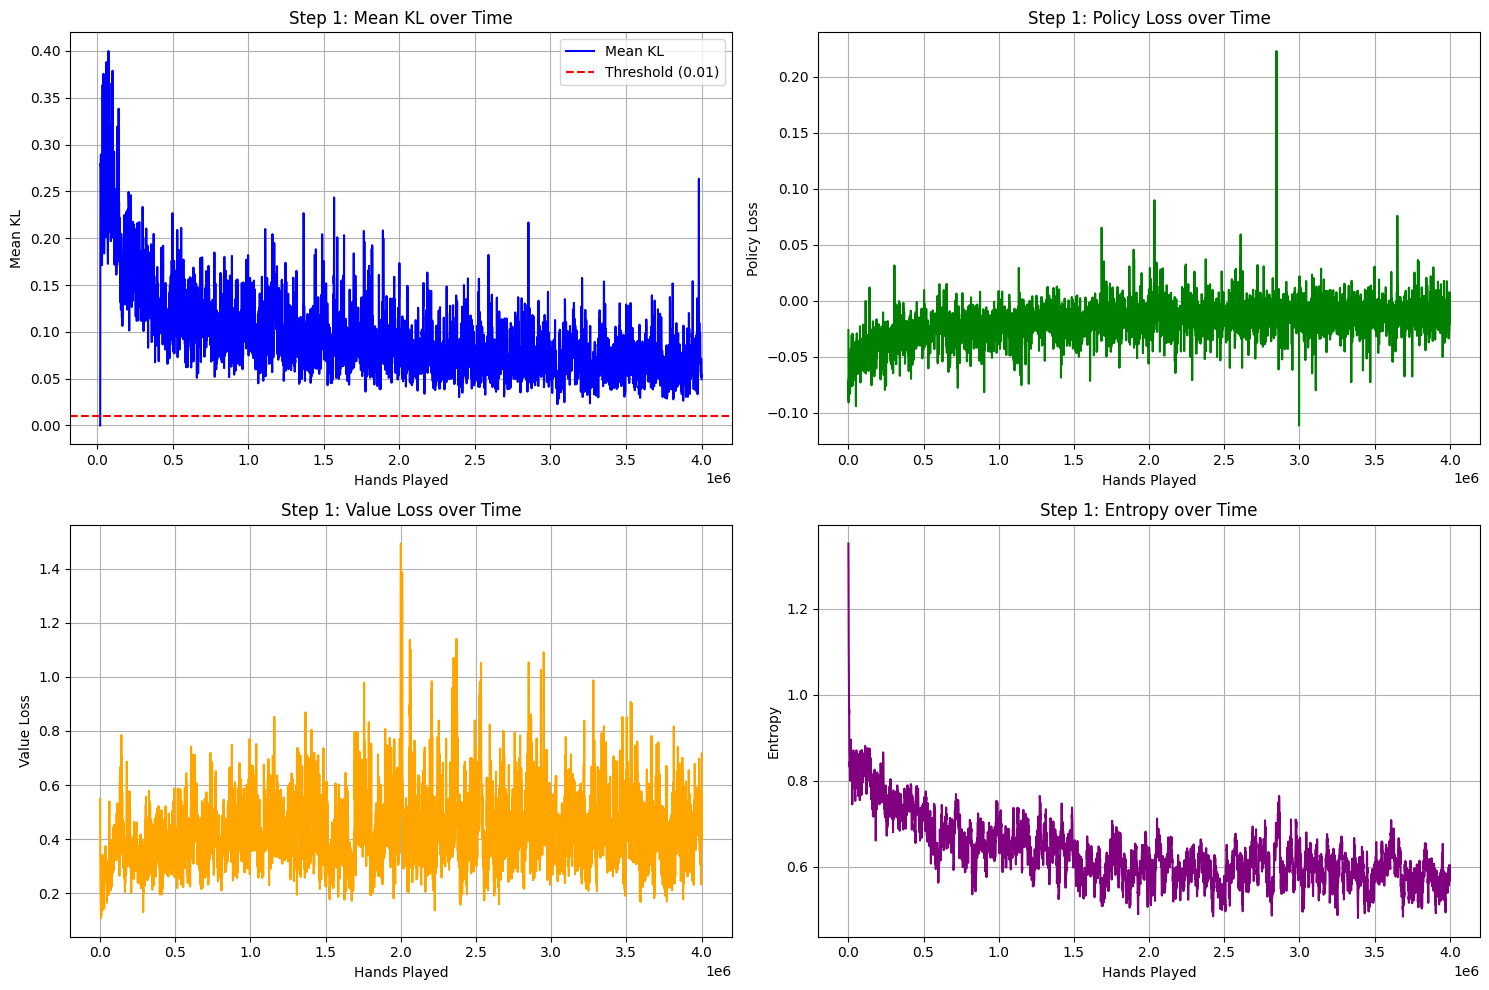

In [6]:

def plot_step1_stats(log_path, output_path):
    if not os.path.exists(log_path):
        print(f"Log file not found at {log_path}")
        return

    with open(log_path, "r") as f:
        log_data = json.load(f)

    hands = [entry["hand"] for entry in log_data]
    
    stats = {
        "mean_kl":     {"label": "Mean KL",     "color": "blue", "threshold": 0.01},
        "policy_loss": {"label": "Policy Loss", "color": "green"},
        "value_loss":  {"label": "Value Loss",  "color": "orange"},
        "entropy":     {"label": "Entropy",     "color": "purple"}
    }

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    for i, (key, info) in enumerate(stats.items()):
        values = [entry[key] for entry in log_data]
        axes[i].plot(hands, values, label=info["label"], color=info["color"])
        axes[i].set_xlabel("Hands Played")
        axes[i].set_ylabel(info["label"])
        axes[i].set_title(f"Step 1: {info['label']} over Time")
        axes[i].grid(True)
        if "threshold" in info:
            axes[i].axhline(y=info["threshold"], color='r', linestyle='--', label=f"Threshold ({info['threshold']})")
            axes[i].legend()

    plt.tight_layout()
    plt.savefig(output_path)
    print(f"Plot saved to {output_path}")


LOG_FILE = "checkpoints/base_training_log.json"
OUTPUT_FILE = "figs/step1_training_stats.png"
plot_step1_stats(LOG_FILE, OUTPUT_FILE)
plt.show()



In [ ]:
import math
import matplotlib.pyplot as plt

def moving_average(values, window):
    if window <= 1:
        return [v if isinstance(v, (int, float)) and math.isfinite(v) else float("nan") for v in values]

    ma = []
    window_vals = []
    running_sum = 0.0
    running_count = 0

    for v in values:
        if isinstance(v, (int, float)) and math.isfinite(v):
            current = float(v)
            running_sum += current
            running_count += 1
        else:
            current = None

        window_vals.append(current)
        if len(window_vals) > window:
            old = window_vals.pop(0)
            if old is not None:
                running_sum -= old
                running_count -= 1

        ma.append(running_sum / running_count if running_count > 0 else float("nan"))

    return ma

Plot saved to figs/step1_training_stats_ma.png


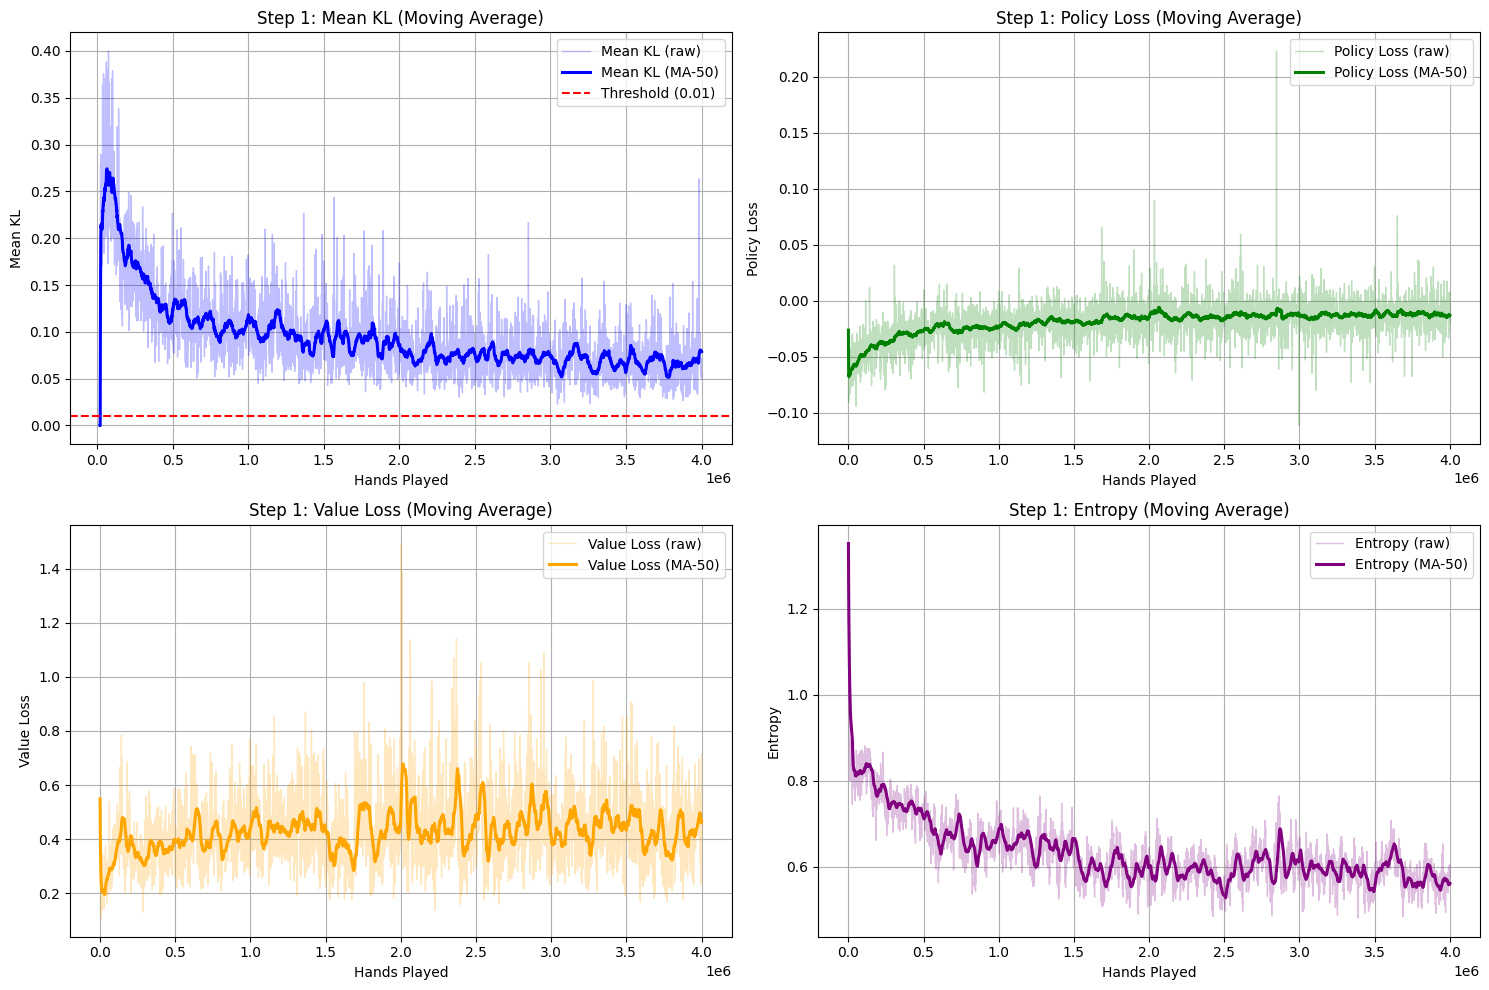

In [14]:

def plot_step1_stats(log_path, output_path, ma_window=50, show_raw=True):
    if not os.path.exists(log_path):
        print(f"Log file not found at {log_path}")
        return

    with open(log_path, "r") as f:
        log_data = json.load(f)

    hands = [entry["hand"] for entry in log_data]

    stats = {
        "mean_kl":     {"label": "Mean KL",     "color": "blue",   "threshold": 0.01},
        "policy_loss": {"label": "Policy Loss", "color": "green"},
        "value_loss":  {"label": "Value Loss",  "color": "orange"},
        "entropy":     {"label": "Entropy",     "color": "purple"}
    }

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    for i, (key, info) in enumerate(stats.items()):
        values = [entry[key] for entry in log_data]
        ma_values = moving_average(values, ma_window)

        if show_raw:
            axes[i].plot(
                hands, values,
                color=info["color"],
                alpha=0.25,
                linewidth=1,
                label=f"{info['label']} (raw)"
            )

        axes[i].plot(
            hands, ma_values,
            color=info["color"],
            linewidth=2.2,
            label=f"{info['label']} (MA-{ma_window})"
        )

        axes[i].set_xlabel("Hands Played")
        axes[i].set_ylabel(info["label"])
        axes[i].set_title(f"Step 1: {info['label']} (Moving Average)")
        axes[i].grid(True)

        if "threshold" in info:
            axes[i].axhline(
                y=info["threshold"],
                color="red",
                linestyle="--",
                linewidth=1.5,
                label=f"Threshold ({info['threshold']})"
            )

        axes[i].legend()

    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    print(f"Plot saved to {output_path}")

LOG_FILE = "checkpoints/base_training_log.json"
OUTPUT_FILE = "figs/step1_training_stats_ma.png"
plot_step1_stats(LOG_FILE, OUTPUT_FILE)
plt.show()

In [12]:
def plot_step2_stats(log_path, output_dir, ma_window=50, show_raw=True):
    if not os.path.exists(log_path):
        print(f"Log file not found at {log_path}")
        return

    with open(log_path, "r") as f:
        log_data = json.load(f)

    if not log_data:
        print("Log is empty.")
        return

    os.makedirs(output_dir, exist_ok=True)

    # Step 2 is seat-specific
    seats = sorted({entry["seat"] for entry in log_data})

    # Keep same core metrics as Step 1, plus Step 2-specific KL penalty
    stats = {
        "mean_kl":     {"label": "Mean KL",     "color": "blue",   "threshold": 0.01},
        "policy_loss": {"label": "Policy Loss", "color": "green"},
        "value_loss":  {"label": "Value Loss",  "color": "orange"},
        "entropy":     {"label": "Entropy",     "color": "purple"},
        "kl_penalty":  {"label": "KL Penalty",  "color": "red"},
    }

    for seat in seats:
        seat_data = [entry for entry in log_data if entry["seat"] == seat]
        hands = [entry["hand"] for entry in seat_data]

        # 3x2 grid for 5 metrics; hide one unused axis
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))
        axes = axes.flatten()

        for i, (key, info) in enumerate(stats.items()):
            values = [entry[key] for entry in seat_data]
            ma_values = moving_average(values, ma_window)

            if show_raw:
                axes[i].plot(
                    hands, values,
                    color=info["color"],
                    alpha=0.25,
                    linewidth=1,
                    label=f"{info['label']} (raw)"
                )

            axes[i].plot(
                hands, ma_values,
                color=info["color"],
                linewidth=2.2,
                label=f"{info['label']} (MA-{ma_window})"
            )

            axes[i].set_xlabel("Hands Played")
            axes[i].set_ylabel(info["label"])
            axes[i].set_title(f"Step 2 Seat {seat}: {info['label']} (Moving Average)")
            axes[i].grid(True)

            if "threshold" in info:
                axes[i].axhline(
                    y=info["threshold"],
                    color="black",
                    linestyle="--",
                    linewidth=1.3,
                    label=f"Threshold ({info['threshold']})"
                )

            axes[i].legend()

        # Hide unused subplot (6th slot)
        for j in range(len(stats), len(axes)):
            axes[j].axis("off")

        plt.tight_layout()
        output_path = os.path.join(output_dir, f"step2_training_stats_seat_{seat}_ma.png")
        plt.savefig(output_path, dpi=150)
        plt.close(fig)
        print(f"Plot for seat {seat} saved to {output_path}")

if __name__ == "__main__":
    LOG_FILE = "checkpoints/perturbed_training_log.json"
    OUTPUT_DIR = "figs"
    plot_step2_stats(LOG_FILE, OUTPUT_DIR, ma_window=50, show_raw=True)

Plot for seat 0 saved to figs/step2_training_stats_seat_0_ma.png
Plot for seat 1 saved to figs/step2_training_stats_seat_1_ma.png
Plot for seat 2 saved to figs/step2_training_stats_seat_2_ma.png
Plot for seat 3 saved to figs/step2_training_stats_seat_3_ma.png
